In [42]:
# =====================================================================
# PLANTILLA GENÉRICA: Clasificación Biclase con Imágenes de Google Drive
# =====================================================================

# ---------------------------------------------------------------------
# PASO 1: Conectar a Google Drive
# ---------------------------------------------------------------------
#from google.colab import drive
#drive.mount('/content/drive')

In [43]:
# ---------------------------------------------------------------------
# PASO 2: Importar Librerías Universales https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
# -------------------------------------------- -------------------------

import cv2
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


In [44]:
# Configuración automática de Hardware (GPU si está activa, si no CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Trabajando con el dispositivo: {device}\n")

# ---------------------------------------------------------------------
# PASO 3: Configurar Rutas del Dataset (¡MODIFICA AQUÍ!)
# ---------------------------------------------------------------------
# Si tu carpeta principal en Drive se llama diferente a "CNN", cambia el nombre aquí.
#RUTA_TRAIN = '/content/drive/MyDrive/CNN/TRAIN/'
#RUTA_TEST = '/content/drive/MyDrive/CNN/TEST/'

RUTA_TRAIN =    'C:\\Users\\Pablo Perez\\Documents\\DSNR\\Modulo_04\\Data_CNNB\\Train'
RUTA_TEST =     'C:\\Users\\Pablo Perez\\Documents\\DSNR\\Modulo_04\\Data_CNNB\\Test'



Trabajando con el dispositivo: cuda



In [45]:
# ---------------------------------------------------------------------
# PASO 4: Transformaciones de Imágenes (Data Augmentation)
# ---------------------------------------------------------------------
# Nota didáctica: ResNet, VGG y la mayoría de redes comerciales esperan 224x224.
# Si tus imágenes son muy grandes o muy chicas, aquí controlas su entrada a la red.
transformaciones_train = transforms.Compose([
    transforms.Resize((224, 224)),           # Redimensionar todas las imágenes al mismo tamaño
    transforms.RandomHorizontalFlip(),       # Volteo aleatorio (Data Augmentation opcional)
    transforms.ToTensor(),                   # Convertir a Tensor de PyTorch en rango [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # Normalización estándar de ImageNet
])

transformaciones_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



In [46]:
# ---------------------------------------------------------------------
# PASO 5: Carga Automática de Datos (ImageFolder)
# ---------------------------------------------------------------------
# ImageFolder mapea automáticamente el nombre de las subcarpetas como las etiquetas.
# Ejemplo: si ve "perros" y "gatos", a perros le asignará 0 y a gatos 1 de forma alfabética.
train_dataset = ImageFolder(root=RUTA_TRAIN, transform=transformaciones_train)
test_dataset = ImageFolder(root=RUTA_TEST, transform=transformaciones_test)

# DataLoaders: Agrupan los datos en lotes (batches)
BATCH_SIZE = 32 # Puedes bajarlo a 16 si te da error de memoria (Out of Memory)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Imprimir las clases detectadas para verificar que todo esté en orden
clases = train_dataset.classes
etiquetas_modelo = train_dataset.class_to_idx

print(f"Clases detectadas en Drive de forma alfabética: {clases}")
print(f"Mapeo de etiquetas: { etiquetas_modelo }")
print(f"Total de imágenes de entrenamiento: {len(train_dataset)}")
print(f"Total de imágenes de prueba: {len(test_dataset)}\n")



Clases detectadas en Drive de forma alfabética: ['Gato', 'Perro']
Mapeo de etiquetas: {'Gato': 0, 'Perro': 1}
Total de imágenes de entrenamiento: 62
Total de imágenes de prueba: 20



In [47]:
# ---------------------------------------------------------------------
# PASO 6: Arquitectura de la Red Convolucional (Modificable)
# ---------------------------------------------------------------------
#class MiCNNClasificador(nn.Module):
#    def __init__(self):
#        super(MiCNNClasificador, self).__init__()

        # Bloque de extracción de características (Convoluciones)
#        self.features = nn.Sequential(
            # Capa 1: Entrada RGB (3 canales), 16 filtros de salida, kernel 3x3
#            nn.Conv2d(3, 16, kernel_size=3, padding=1),
#            nn.ReLU(),
#            nn.MaxPool2d(kernel_size=2, stride=2), # Reduce tamaño a la mitad (112x112)

            # Capa 2: Recibe 16 canales, genera 32 filtros
#            nn.Conv2d(16, 32, kernel_size=3, padding=1),
#            nn.ReLU(),
#            nn.MaxPool2d(kernel_size=2, stride=2)  # Reduce tamaño a la mitad (56x56)
 #       )

        # Bloque de Clasificación (Capas Densas / Lineales)
        # 32 canales * 56 de alto * 56 de ancho = 100,352 neuronas de entrada al aplanar
#        self.classifier = nn.Sequential(
#            nn.Linear(32 * 56 * 56, 128),
#            nn.ReLU(),
#            nn.Dropout(0.5), # Evita el sobreajuste (overfitting) apagando el 50% de neuronas al azar
#            nn.Linear(128, 2) # SALIDA = 2 porque es clasificación biclase (Clase A vs Clase B)
#        )

#    def forward(self, x):
#        x = self.features(x)
#        x = x.view(x.size(0), -1) # Aplanar el mapa de características 2D a 1D
#        x = self.classifier(x)
#        return x

# Instanciar el modelo y enviarlo a la GPU/CPU
#model = MiCNNClasificador().to(device)



In [48]:
# CAMBIO PARA USAR TRANSFER LEARNING:
import torchvision.models as models
 
# 1. Cargamos una estructura ya existente con pesos preentrenados en ImageNet
pesos = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=pesos)
 
# 2. CONGELAMOS las capas base para aprovechar su conocimiento (no se entrenarán)
for param in model.parameters():
    param.requires_grad = False
 
# 3. REEMPLAZAMOS únicamente la última capa (la cabeza de clasificación)
# Conservamos sus características de entrada (512) y le decimos que la salida ahora es 2 (biclase)
num_caracteristicas = model.fc.in_features
model.fc = nn.Linear(num_caracteristicas, 2)
 
# 4. Lo enviamos al hardware
model = model.to(device)

In [49]:
# ---------------------------------------------------------------------
# PASO 7: Función de Pérdida y Optimidad
# ---------------------------------------------------------------------
criterion = nn.CrossEntropyLoss() # Ideal para clasificación
optimizer = optim.Adam(model.parameters(), lr=0.001) # Ritmo de aprendizaje (Learning Rate)

# ---------------------------------------------------------------------
# PASO 8: Bucle de Entrenamiento (Training Loop)
# ---------------------------------------------------------------------
NUM_EPOCHS = 30# Modifica el número de épocas según requieras más entrenamiento
print("Iniciando el entrenamiento de la red...")

for epoch in range(NUM_EPOCHS):
    model.train()
    loss_acumulada = 0.0

    for imagenes, etiquetas in train_loader:
        # Mover datos al hardware seleccionado
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        # Forward pass
        predicciones = model(imagenes)
        loss = criterion(predicciones, etiquetas)

        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_acumulada += loss.item()

    print(f"Época [{epoch+1}/{NUM_EPOCHS}] - Pérdida Promedio: {loss_acumulada/len(train_loader):.4f}")

print("¡Entrenamiento concluido!\n")



Iniciando el entrenamiento de la red...
Época [1/30] - Pérdida Promedio: 0.7019
Época [2/30] - Pérdida Promedio: 0.5912
Época [3/30] - Pérdida Promedio: 0.4930
Época [4/30] - Pérdida Promedio: 0.4167
Época [5/30] - Pérdida Promedio: 0.3658
Época [6/30] - Pérdida Promedio: 0.3015
Época [7/30] - Pérdida Promedio: 0.2743
Época [8/30] - Pérdida Promedio: 0.2374
Época [9/30] - Pérdida Promedio: 0.1946
Época [10/30] - Pérdida Promedio: 0.2028
Época [11/30] - Pérdida Promedio: 0.1769
Época [12/30] - Pérdida Promedio: 0.1540
Época [13/30] - Pérdida Promedio: 0.1451
Época [14/30] - Pérdida Promedio: 0.1246
Época [15/30] - Pérdida Promedio: 0.1185
Época [16/30] - Pérdida Promedio: 0.1023
Época [17/30] - Pérdida Promedio: 0.1033
Época [18/30] - Pérdida Promedio: 0.1018
Época [19/30] - Pérdida Promedio: 0.0906
Época [20/30] - Pérdida Promedio: 0.0975
Época [21/30] - Pérdida Promedio: 0.1050
Época [22/30] - Pérdida Promedio: 0.0724
Época [23/30] - Pérdida Promedio: 0.0615
Época [24/30] - Pérdida Pr

In [50]:
# ---------------------------------------------------------------------
# PASO 9: Evaluación Final en el Set de Prueba (Test)
# ---------------------------------------------------------------------
model.eval()
correctos = 0
total_imagenes = 0

# Desactivamos el cálculo de gradientes para ir más rápido y ahorrar memoria
with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        outputs = model(imagenes)
        _, predicciones_indices = torch.max(outputs.data, 1)

        total_imagenes += etiquetas.size(0)
        correctos += (predicciones_indices == etiquetas).sum().item()

accuracy = 100 * correctos / total_imagenes
print(f"Exactitud (Accuracy) en el conjunto de TEST: {accuracy:.2f}%")


Exactitud (Accuracy) en el conjunto de TEST: 100.00%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.622571].


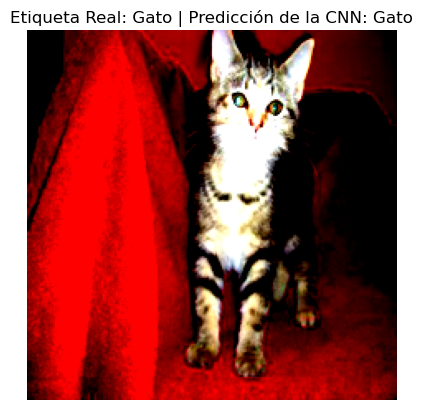

In [51]:
# ---------------------------------------------------------------------
# PASO 10: Visualización de Resultados 
# ---------------------------------------------------------------------

imagenes_muestra, etiquetas_muestra = next(iter(test_loader))
con_prediccion = model(imagenes_muestra.to(device))
_, prediccion = torch.max(con_prediccion, 1)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

# Dibujar el primer elemento del lote
plt.imshow(imagenes_muestra[0].squeeze().numpy().transpose(1, 2, 0))
plt.title(f"Etiqueta Real: {idx_to_class[etiquetas_muestra[0].item()]} | Predicción de la CNN: {idx_to_class[prediccion[0].item()]}")
plt.axis('off')
plt.show()

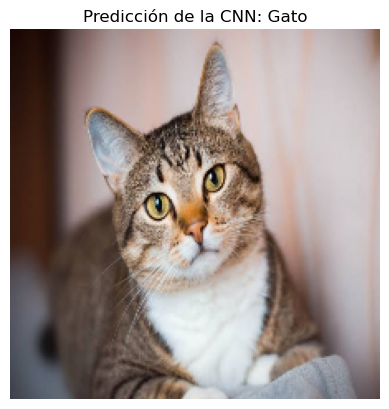

In [52]:
# ---------------------------------------------------------------------
# PASO 11: Prueba con una Imagen Externa 
# ---------------------------------------------------------------------

img = cv2.imread( 'kitten.jpg')
image_resized = cv2.resize(img, (224, 224))
img_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

tensor_kitten = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
tensor_kitten = tensor_kitten.unsqueeze(0)

con_prediccion = model(tensor_kitten.to(device))
_, prediccion = torch.max(con_prediccion, 1)

# Dibujar el primer elemento del lote
plt.imshow(tensor_kitten.squeeze().numpy().transpose(1, 2, 0))
plt.title(f"Predicción de la CNN: {idx_to_class[prediccion[0].item()]}")
plt.axis('off')
plt.show()

